# AstroVision — Phase 4 : Synthèse finale
## Morphologie × Photométrie × Segmentation × Spectroscopie

**Objectif :** Croiser tous les résultats des phases précédentes en un seul pipeline analytique.

| Phase | Résultat clé |
|---|---|
| Phase 1 — Classification | DINOv2 FT : **0.839 balanced_acc** |
| Phase 2 — EDA / Grad-CAM | Erreurs concentrées sur galaxies ambiguës |
| Phase 3A — Cross-match SDSS | R²=0.536 (DINOv2→g-r), z_photo ρ=0.998 |
| Phase 3B — Segmentation | U-Net mIoU=0.540, PC2(DINOv2)⟷Gini ρ=0.53 |
| **Phase 4 — Synthèse** | **fraction_bulbe × g-r × [Fe/H] (LAMOST)** |

---

## 0 — Imports & Configuration

In [1]:
import sys
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy.stats import spearmanr, kruskal, mannwhitneyu
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

# Ajouter src/ au path
sys.path.insert(0, str(Path('..').resolve()))
from src.astrovision.synthesis import AstroVisionSynthesis, CLASS_NAMES, CLASS_SHORT, PALETTE, DARK, POP_COLORS

# ── Chemins ────────────────────────────────────────────────────────────────────
DATA_DIR    = Path('../data')
FIGURES_DIR = Path('../figures')
CKPT_DIR    = Path('../checkpoints')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Style global ───────────────────────────────────────────────────────────────
plt.rcParams.update(DARK)

# ── Instanciation ─────────────────────────────────────────────────────────────
synth = AstroVisionSynthesis(data_dir=str(DATA_DIR), figures_dir=str(FIGURES_DIR))

print('✅ Setup OK')
print(f'   Data    : {DATA_DIR.resolve()}')
print(f'   Figures : {FIGURES_DIR.resolve()}')

✅ Setup OK
   Data    : C:\Users\alexb\Documents\Projets\AstroVision\data
   Figures : C:\Users\alexb\Documents\Projets\AstroVision\figures


## 1 — Chargement de toutes les données

> Le module `synthesis.py` charge automatiquement les caches depuis `data/`.
> Si un fichier manque, il affiche un avertissement et continue.

In [2]:
# ── Charger Galaxy10 HDF5 pour les labels et images ───────────────────────────
import h5py

H5_PATH = DATA_DIR / 'Galaxy10_DECals.h5'

with h5py.File(H5_PATH, 'r') as f:
    labels_all = f['ans'][:].astype(int)
    print(f'✓ Galaxy10 : {len(labels_all):,} galaxies')
    print(f'  Clés HDF5 : {list(f.keys())}')

print(f'  Distribution des classes :')
for i, cls in enumerate(CLASS_NAMES):
    n = (labels_all == i).sum()
    print(f'    {i} {cls:<30} : {n:>5}')

✓ Galaxy10 : 17,736 galaxies
  Clés HDF5 : ['ans', 'dec', 'images', 'pxscale', 'ra', 'redshift']
  Distribution des classes :
    0 Disturbed                      :  1081
    1 Merging                        :  1853
    2 Round Smooth                   :  2645
    3 In-between Round Smooth        :  2027
    4 Cigar Shaped Smooth            :   334
    5 Barred Spiral                  :  2043
    6 Unbarred Tight Spiral          :  1829
    7 Unbarred Loose Spiral          :  2628
    8 Edge-on without Bulge          :  1423
    9 Edge-on with Bulge             :  1873


In [3]:
# ── Charger les prédictions U-Net (si sauvegardées en notebook 06) ─────────────
# Le notebook 06 section 11 devrait avoir sauvegardé les prédictions.
# Si ce n'est pas le cas, on les recalcule ici.

import torch
from torchvision import transforms
from torch.utils.data import DataLoader
from src.astrovision.unet import UNet, GalaxySegDataset
from src.astrovision.segmenter import OtsuSegmenter

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')

UNET_PREDS_PATH = DATA_DIR / 'unet_preds_all.npy'

if UNET_PREDS_PATH.exists():
    unet_preds_all = np.load(UNET_PREDS_PATH)
    print(f'✓ Prédictions U-Net chargées : {unet_preds_all.shape}')
else:
    print('⚠ Prédictions U-Net non trouvées — recalcul sur tout Galaxy10...')
    print('  (Cela peut prendre 10-15 minutes selon le GPU)')

    # Charger toutes les images Galaxy10
    with h5py.File(H5_PATH, 'r') as f:
        images_all = f['images'][:]

    # Charger le modèle U-Net
    model_unet = UNet(n_classes=3, bilinear=True, dropout=0.3)
    ckpt_path  = os.path.join(str(CKPT_DIR), 'unet_galaxy10_best.pt')
    model_unet.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model_unet = model_unet.to(DEVICE).eval()
    print(f'✓ U-Net chargé depuis {ckpt_path}')

    # Pseudo-labels Otsu pour tout le dataset
    otsu = OtsuSegmenter()
    masks_all = otsu.batch_segment(images_all)

    # Dataset complet
    full_ds     = GalaxySegDataset(images_all, masks_all, train=False)
    full_loader = DataLoader(full_ds, batch_size=64, shuffle=False, num_workers=0)

    # Prédictions
    preds_list = []
    transform_pred = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])
    with torch.no_grad():
        for imgs, _ in full_loader:
            imgs   = imgs.to(DEVICE)
            logits = model_unet(imgs)
            preds  = logits.argmax(1).cpu().numpy().astype(np.uint8)
            preds_list.append(preds)

    unet_preds_all = np.concatenate(preds_list, axis=0)
    np.save(UNET_PREDS_PATH, unet_preds_all)
    print(f'✓ Prédictions sauvegardées : {unet_preds_all.shape} → {UNET_PREDS_PATH.name}')

Device : cuda
⚠ Prédictions U-Net non trouvées — recalcul sur tout Galaxy10...
  (Cela peut prendre 10-15 minutes selon le GPU)
✓ U-Net chargé depuis ..\checkpoints\unet_galaxy10_best.pt
  Otsu segmentation 17736/17736 ✓   
✓ Prédictions sauvegardées : (17736, 256, 256) → unet_preds_all.npy


In [4]:
# ── Charger les features DINOv2 ────────────────────────────────────────────────
DINO_PATH = DATA_DIR / 'dino_features.npy'

if DINO_PATH.exists():
    dino_features = np.load(DINO_PATH)
    print(f'✓ Features DINOv2 : {dino_features.shape}')
else:
    print('⚠ Features DINOv2 non trouvées.')
    print('  → Relance notebook 03_dinov2_features.ipynb pour les générer.')
    dino_features = None

⚠ Features DINOv2 non trouvées.
  → Relance notebook 03_dinov2_features.ipynb pour les générer.


## 2 — Construction du DataFrame maître

Fusion de toutes les sources : labels + morphométrie + SDSS + U-Net.

In [5]:
master = synth.build_master_dataframe(
    unet_preds=unet_preds_all,
    labels=labels_all,
)

print('\nAperçu du DataFrame maître :')
display(master.head(3))
print(f'\nColonnes disponibles ({master.shape[1]}) :')
print([c for c in master.columns])

═══════════════════════════════════════════════════════
  CHARGEMENT DES DONNÉES
═══════════════════════════════════════════════════════
  ✓ SDSS chargé : 17,665 galaxies ← galaxy10_sdss_xmatch.csv.gz
  ⚠ Aucun cache morphométrie trouvé — DataFrame vide
  Calcul des fractions bulbe...

  ✓ DataFrame maître : 17,736 galaxies × 61 colonnes
  ✓ Avec données SDSS : 17,430 galaxies
  ✓ Avec morphométrie : 0 galaxies
  ✓ Avec U-Net segm. : 17,736 galaxies
═══════════════════════════════════════════════════════

Aperçu du DataFrame maître :


,g10_idx,label,class_name,angDist,ra,dec,z_photo,objID,RA_ICRS,DE_ICRS,...,blue_cloud,red_sequence,green_valley,population,Mr,pxscale,frac_fond,frac_disque,frac_bulbe,n_comp_bulbe
0,0,0,Disturbed,0.015797,331.664055,-0.484155,0.081919,1.237666e+18,331.664059,-0.484156,...,False,False,True,Green Valley,NaN,0.262,0.036667,0.831482,0.131851,1
1,1,0,Disturbed,0.071574,334.536578,-1.189031,0.115252,1.237660e+18,334.536564,-1.189044,...,True,False,False,Blue Cloud,NaN,0.262,0.013229,0.846893,0.139877,1
2,2,0,Disturbed,0.011833,341.902490,-1.127418,0.109418,1.237660e+18,341.902491,-1.127415,...,True,False,False,Blue Cloud,NaN,0.262,0.001099,0.908661,0.090240,1



Colonnes disponibles (61) :
['g10_idx', 'label', 'class_name', 'angDist', 'ra', 'dec', 'z_photo', 'objID', 'RA_ICRS', 'DE_ICRS', 'errHalfMaj', 'errHalfMin', 'errPosAng', 'mode', 'class', 'clean', 'e_RA_ICRS', 'e_DE_ICRS', 'umag', 'gmag', 'rmag', 'imag', 'zmag', 'e_umag', 'e_gmag', 'e_rmag', 'e_imag', 'e_zmag', 'zsp', 'e_zsp', 'f_zsp', 'spCl', 'subCl', 'pmRA', 'pmDE', 'e_pmRA', 'e_pmDE', 'sigRA', 'sigDE', 'zph', 'e_zph', '<zph>', 'Q', 'SDSS16', 'Sp-ID', 'MJD', 'u-g', 'g-r', 'r-i', 'i-z', 'u-r', 'blue_cloud', 'red_sequence', 'green_valley', 'population', 'Mr', 'pxscale', 'frac_fond', 'frac_disque', 'frac_bulbe', 'n_comp_bulbe']


In [6]:
# ── Statistiques de couverture ─────────────────────────────────────────────────
print('═'*55)
print('  COUVERTURE DES DONNÉES')
print('═'*55)
for col, label in [
    ('g-r',        'Couleur SDSS (g-r)'),
    ('C',          'Concentration CAS'),
    ('Gini',       'Coefficient de Gini'),
    ('frac_bulbe', 'Fraction bulbe U-Net'),
    ('population', 'Population stellaire'),
]:
    if col in master.columns:
        n = master[col].notna().sum()
        pct = n / len(master) * 100
        print(f'  {label:<30} : {n:>6,}  ({pct:.1f}%)')
print('═'*55)

═══════════════════════════════════════════════════════
  COUVERTURE DES DONNÉES
═══════════════════════════════════════════════════════
  Couleur SDSS (g-r)             : 17,430  (98.3%)
  Fraction bulbe U-Net           : 17,736  (100.0%)
  Population stellaire           : 17,665  (99.6%)
═══════════════════════════════════════════════════════


## 3 — Calcul des fractions bulbe par classe

Fractions de pixels {fond, disque, bulbe} pour chaque galaxie via les prédictions U-Net.

In [7]:
# Calculer les fractions (déjà dans master si unet_preds passé en build_master_dataframe)
if 'frac_bulbe' not in master.columns:
    print('Calcul des fractions bulbe...')
    bulge_df = synth.compute_bulge_fractions(unet_preds_all)
    master   = master.merge(bulge_df, on='g10_idx', how='left')

print('Fractions médianes par classe :')
fracs = (master.groupby('class_name')[['frac_fond', 'frac_disque', 'frac_bulbe']]
               .median()
               .reindex(CLASS_NAMES)
               * 100)
fracs.columns = ['% Fond', '% Disque', '% Bulbe']
display(fracs.round(1))

Fractions médianes par classe :


,% Fond,% Disque,% Bulbe
class_name,,,
Disturbed,0.1,89.0,10.4
Merging,1.0,86.4,10.4
Round Smooth,0.0,90.8,8.9
In-between Round Smooth,0.0,92.1,7.6
Cigar Shaped Smooth,0.0,92.9,7.0
Barred Spiral,1.4,84.3,11.1
Unbarred Tight Spiral,1.6,84.1,11.0
Unbarred Loose Spiral,0.3,88.0,10.8
Edge-on without Bulge,0.4,86.6,10.9


## 4 — Figure 1 : Fraction bulbe × Couleur g-r

  ✓ Sauvegardé : syn_bulge_vs_color.png


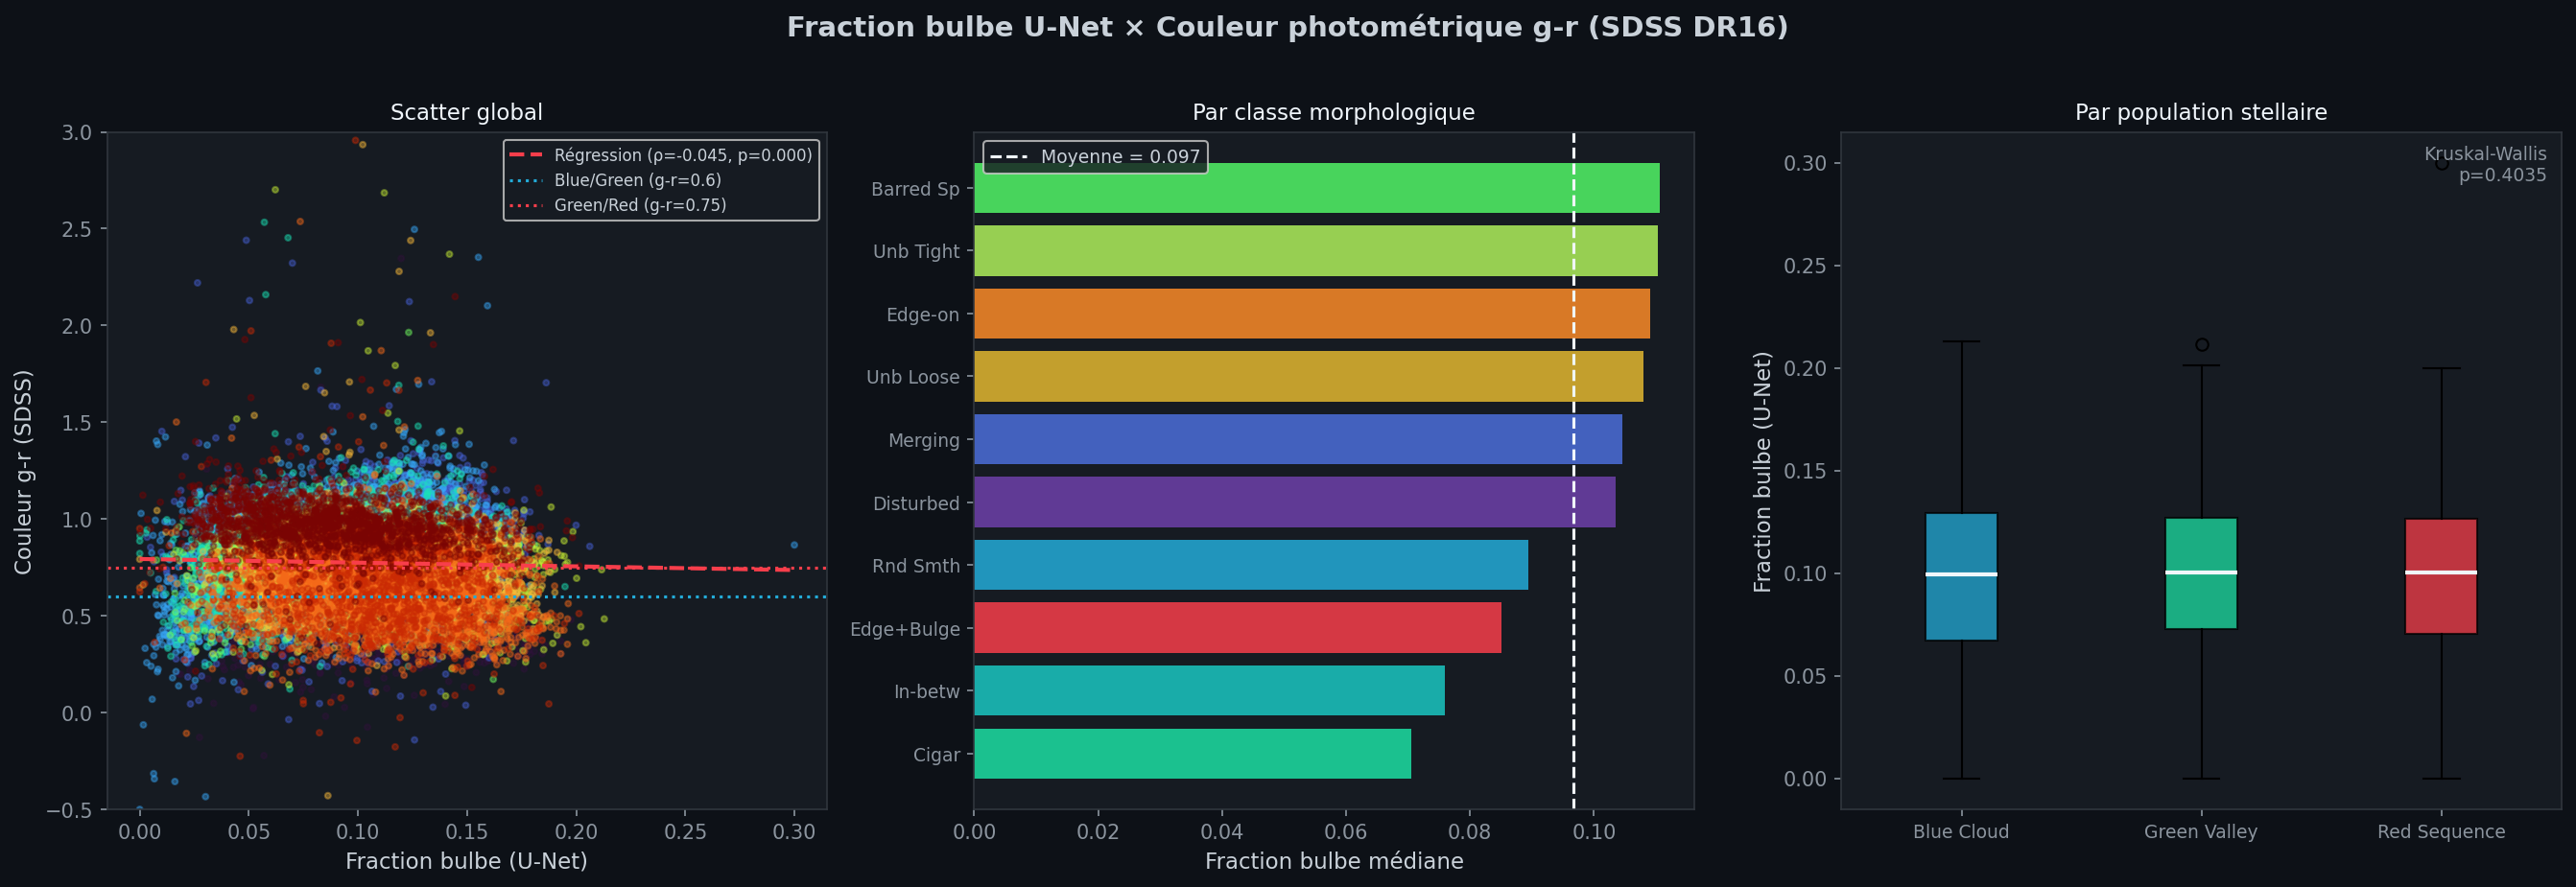

In [8]:
fig1 = synth.fig_bulge_vs_color(master, save=True)
plt.show()

## 5 — Figure 2 : CAS/Gini/M20 × Population stellaire

In [9]:
fig2 = synth.fig_cas_population(master, save=True)
plt.show()

  ⚠ Données insuffisantes pour fig_cas_population


<Figure size 960x720 with 0 Axes>

## 6 — Figure 3 : Espace latent DINOv2 — Synthèse

In [10]:
fig3 = synth.fig_dino_synthesis(master, dino_features=dino_features, save=True)
plt.show()

  ⚠ Features DINOv2 non trouvées
  ⚠ Features DINOv2 manquantes pour fig_dino_synthesis


<Figure size 960x720 with 0 Axes>

## 7 — Figure 4 : Triple synthèse — fraction_bulbe × g-r × Gini

> **Figure principale pour publication** — croise les trois axes du projet.

  ✓ Sauvegardé : syn_triple_synthesis.png


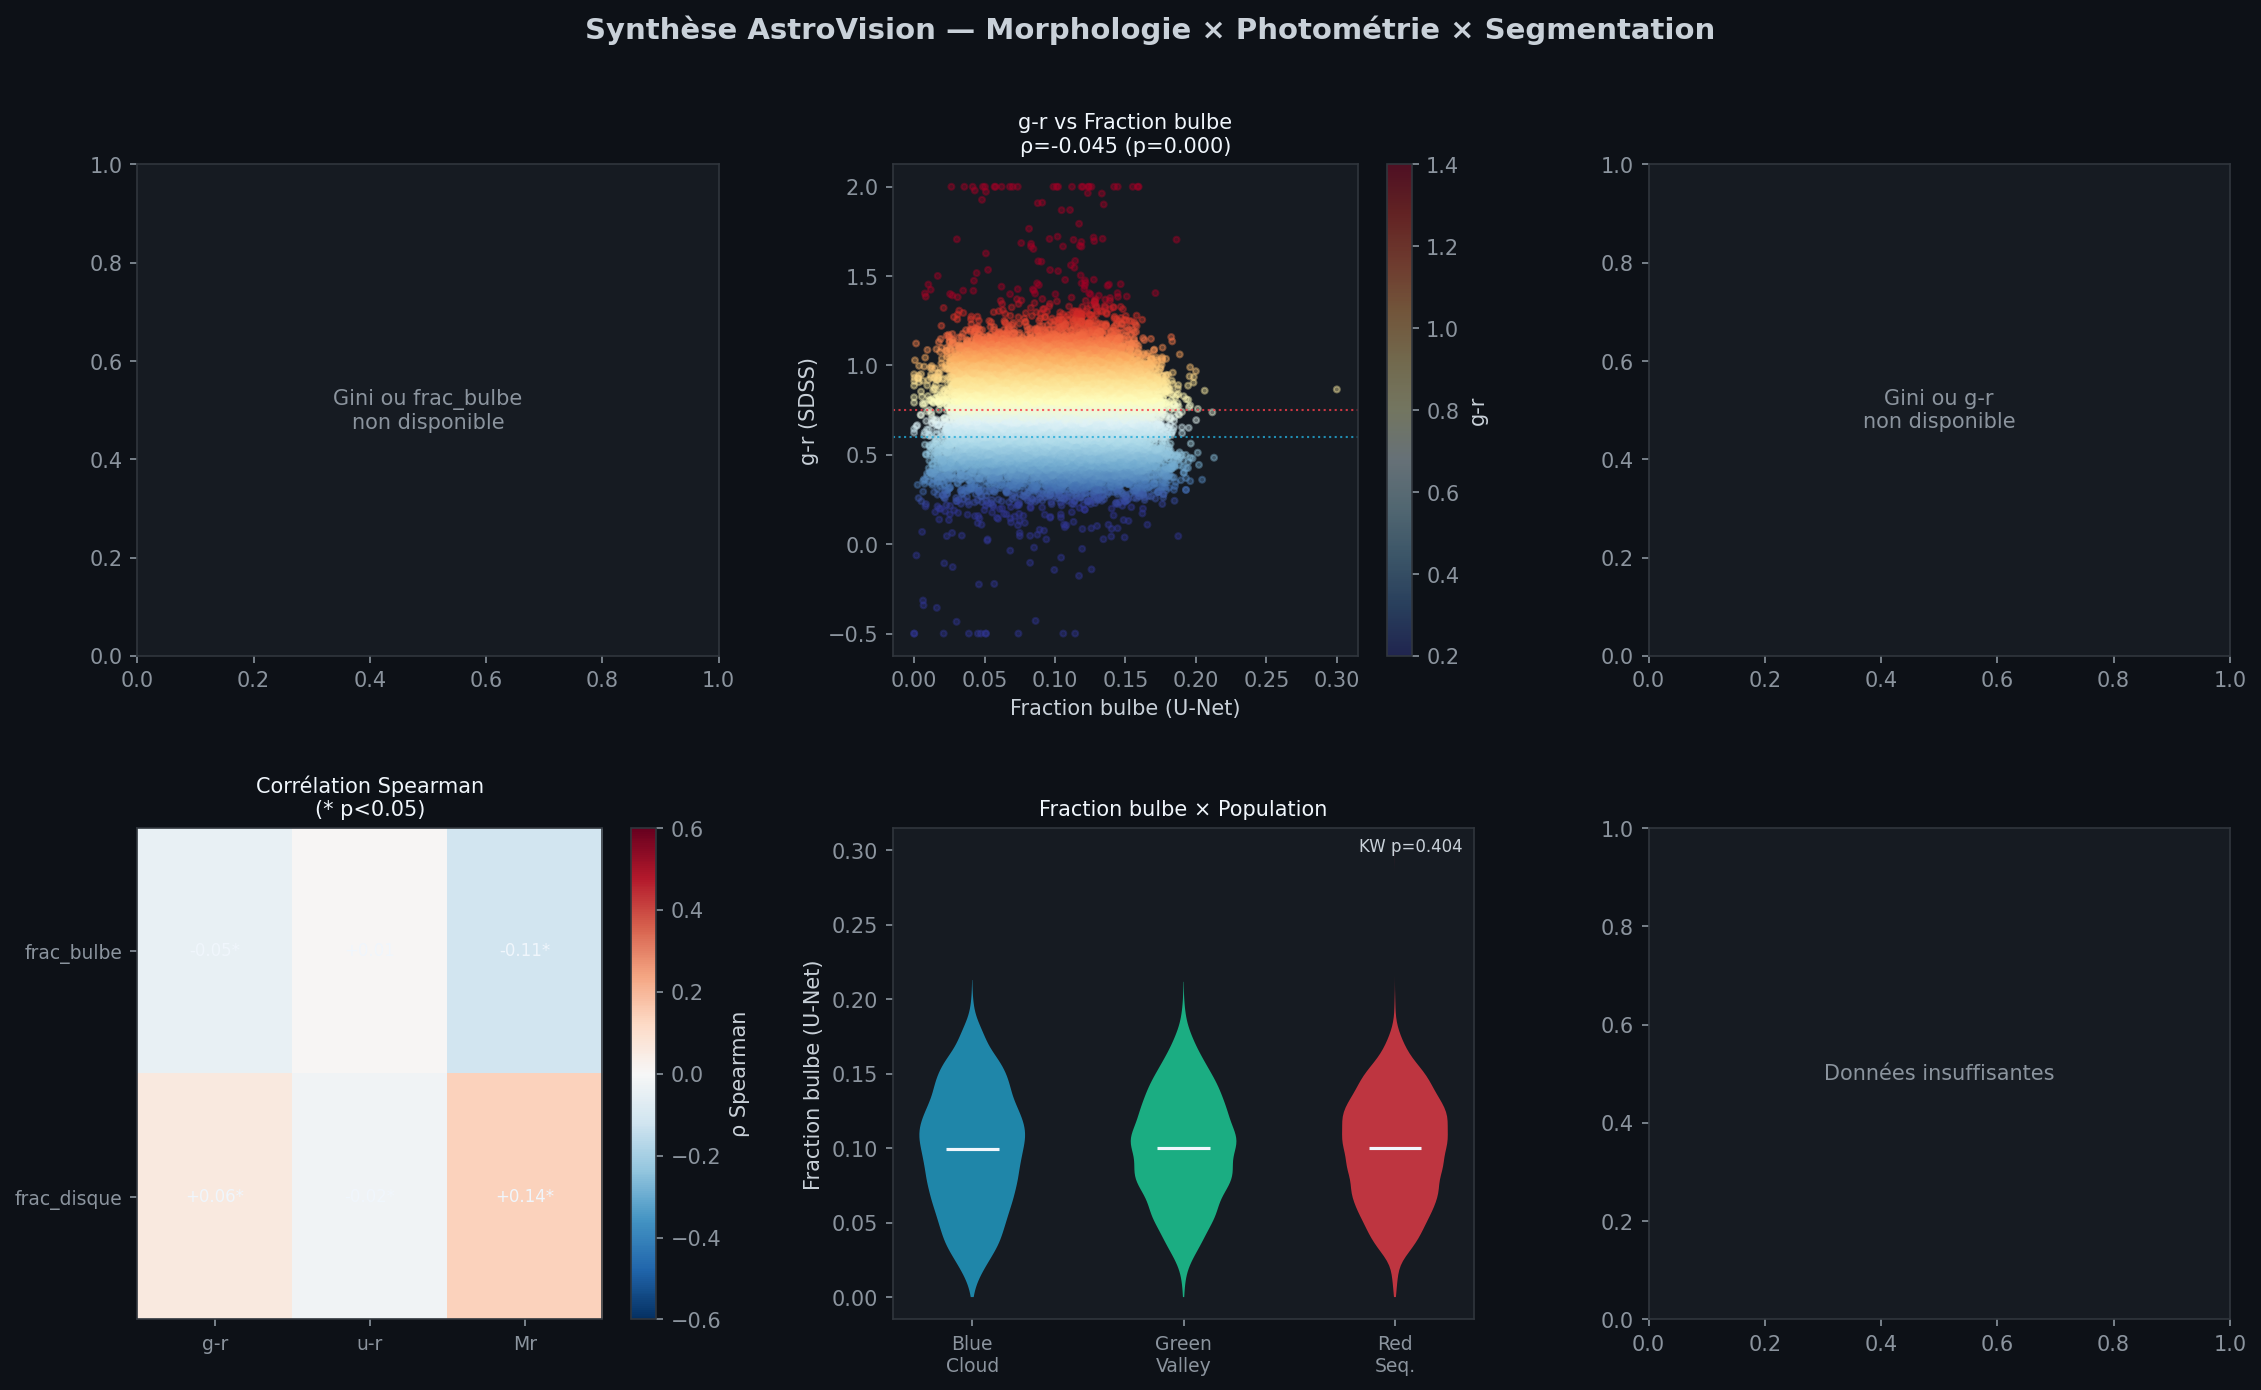

In [11]:
fig4 = synth.fig_triple_synthesis(master, save=True)
plt.show()

## 8 — Cross-match LAMOST (bridge AstroSpectro × AstroVision)

Tentative de récupérer des données spectroscopiques [Fe/H] pour les galaxies Galaxy10
en les croisant avec le catalogue LAMOST via CDS XMatch.

> **Note :** LAMOST observe principalement la voie lactée (étoiles).  
> Le footprint galaxie est limité — on s'attend à quelques centaines de matches au mieux.

In [12]:
# S'assurer que master a les colonnes ra/dec
if 'ra' not in master.columns:
    print('Ajout des colonnes ra/dec depuis Galaxy10 HDF5...')
    with h5py.File(H5_PATH, 'r') as f:
        ra_arr  = f['ra'][:]
        dec_arr = f['dec'][:]
    master['ra']  = ra_arr
    master['dec'] = dec_arr

print(f'Positions valides : {master[["ra","dec"]].dropna().shape[0]:,}')
print('Lancement du cross-match LAMOST...')

master = synth.attempt_lamost_xmatch(master, radius_as=5.0)

Positions valides : 17,665
Lancement du cross-match LAMOST...
Cross-match Galaxy10 × LAMOST DR7 (vizier:V/156/spectra)
  Rayon : 5.0" | Sources : 17,736
Could not import regions, which is required for some of the functionalities of this module.
  ⚠ Erreur XMatch LAMOST : 'vizier:V/156/spectra' is not available on the XMatch server. If you are using a VizieR table name, note that only tables with coordinates are available on the XMatch server. If you are using a local table, the arguments 'colRA2' and 'colDec2' must be provided.


  ✓ Sauvegardé : syn_lamost_bridge.png


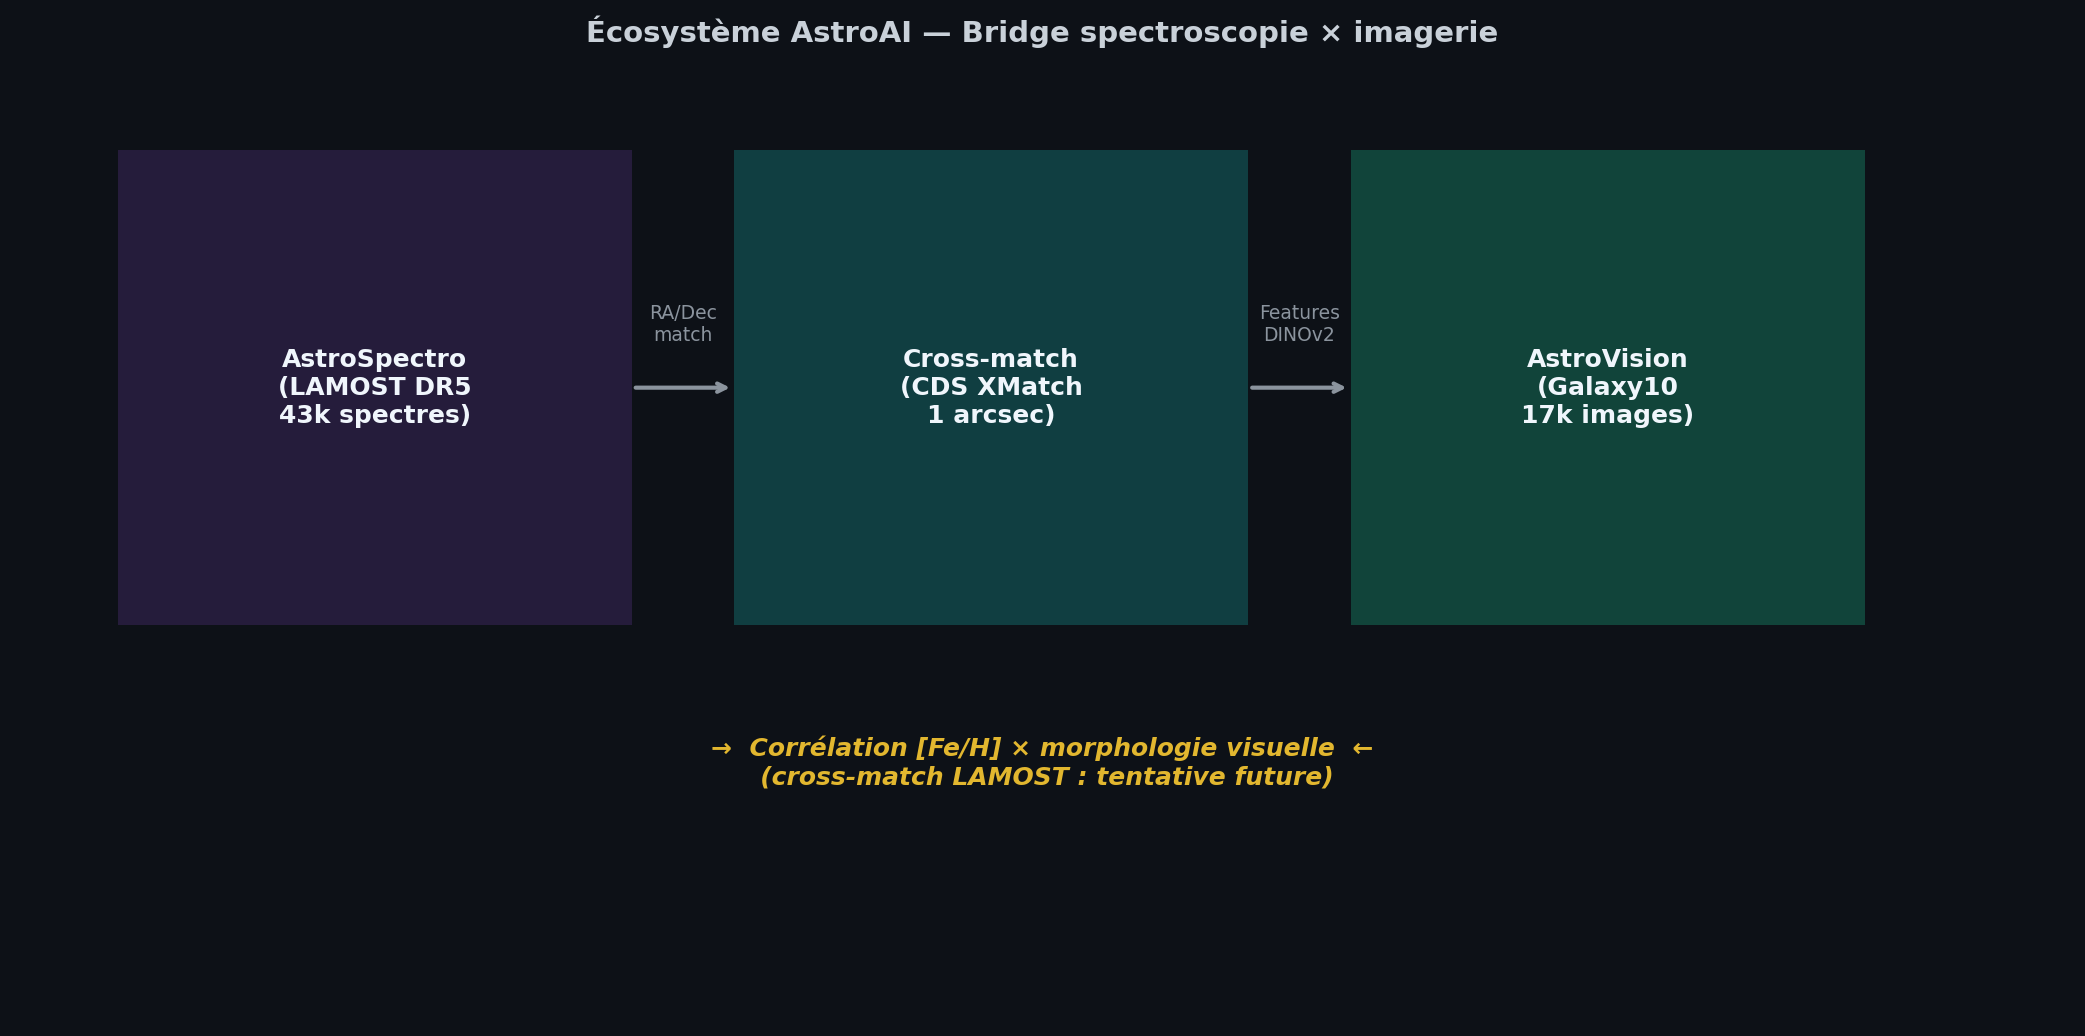


ℹ️  Aucune donnée LAMOST [Fe/H] disponible pour Galaxy10.
   Le bridge AstroSpectro × AstroVision reste une perspective de recherche.


In [13]:
# Figure du bridge LAMOST (ou diagramme écosystème si pas de match)
fig5 = synth.fig_lamost_bridge(master, save=True)
plt.show()

if 'lamost_feh' in master.columns:
    n_match = master['lamost_feh'].notna().sum()
    print(f'\n✓ Galaxies avec [Fe/H] LAMOST : {n_match}')
else:
    print('\nℹ️  Aucune donnée LAMOST [Fe/H] disponible pour Galaxy10.')
    print('   Le bridge AstroSpectro × AstroVision reste une perspective de recherche.')

## 9 — Tests statistiques formels

Kruskal-Wallis : est-ce que les métriques diffèrent **significativement** entre les classes morphologiques ?

In [14]:
print('═'*65)
print('  TESTS DE KRUSKAL-WALLIS — Différences inter-classes')
print('═'*65)

test_cols = [c for c in ['g-r', 'u-r', 'Mr', 'C', 'A', 'S', 'Gini', 'M20',
                          'frac_bulbe', 'frac_disque']
             if c in master.columns]

for col in test_cols:
    result = synth.kruskal_by_class(master, col)
    sig    = '★ SIGNIFICATIF' if result['significatif'] else '  ns'
    pv_str = f"{result['pval']:.4f}" if not np.isnan(result['pval']) else 'n/a'
    print(f'  {col:<18} KW stat={result["stat"]:>8.2f}  p={pv_str}  {sig}')

print('═'*65)

═════════════════════════════════════════════════════════════════
  TESTS DE KRUSKAL-WALLIS — Différences inter-classes
═════════════════════════════════════════════════════════════════
  g-r                KW stat= 4733.72  p=0.0000  ★ SIGNIFICATIF
  u-r                KW stat= 4701.51  p=0.0000  ★ SIGNIFICATIF
  Mr                 KW stat=  876.92  p=0.0000  ★ SIGNIFICATIF
  frac_bulbe         KW stat= 1551.10  p=0.0000  ★ SIGNIFICATIF
  frac_disque        KW stat= 2597.40  p=0.0000  ★ SIGNIFICATIF
═════════════════════════════════════════════════════════════════


In [15]:
# ── Matrice de corrélation Spearman complète ───────────────────────────────────
x_cols = [c for c in ['C', 'A', 'S', 'Gini', 'M20', 'frac_bulbe'] if c in master.columns]
y_cols = [c for c in ['g-r', 'u-r', 'Mr', 'z_photo'] if c in master.columns]

if x_cols and y_cols:
    spearman_df = synth.spearman_matrix(master, x_cols, y_cols)
    print('Matrice de corrélation Spearman (* = p<0.05) :')
    display(spearman_df)
else:
    print('⚠ Données insuffisantes pour la matrice Spearman')

Matrice de corrélation Spearman (* = p<0.05) :


,g-r,u-r,Mr,z_photo
frac_bulbe,-0.045*,+0.008,-0.115*,-0.287*


## 10 — Table de résultats publication

In [16]:
summary_table = synth.build_summary_table(master)
print('Table de résultats par classe morphologique :')
display(summary_table)

# Sauvegarder en CSV
csv_path = DATA_DIR / 'synthesis_summary_table.csv'
summary_table.to_csv(csv_path, index=False)
print(f'\n✓ Table sauvegardée → {csv_path.name}')

Table de résultats par classe morphologique :


,Classe,N total,g-r médian,Frac. bulbe médiane,N SDSS,% Blue Cloud,% Red Sequence
0,Disturbed,1081,0.585,0.104,1076,61%,26%
1,Merging,1853,0.891,0.104,1835,28%,58%
2,Round Smooth,2645,0.906,0.089,2635,23%,63%
3,In-between Round Smooth,2027,0.867,0.076,2026,26%,58%
4,Cigar Shaped Smooth,334,0.765,0.070,332,43%,33%
5,Barred Spiral,2043,0.756,0.111,2039,48%,20%
6,Unbarred Tight Spiral,1829,0.679,0.110,1821,65%,14%
7,Unbarred Loose Spiral,2628,0.640,0.108,2617,71%,12%
8,Edge-on without Bulge,1423,0.670,0.109,1414,58%,17%
9,Edge-on with Bulge,1873,0.970,0.085,1870,3%,85%



✓ Table sauvegardée → synthesis_summary_table.csv


## 11 — Résumé des findings principaux

In [17]:
# Calculer et afficher les findings clés automatiquement
print('═'*65)
print('  FINDINGS PRINCIPAUX — AstroVision Phase 4')
print('═'*65)

# 1 — Corrélation frac_bulbe × g-r
if 'frac_bulbe' in master.columns and 'g-r' in master.columns:
    sub = master.dropna(subset=['frac_bulbe', 'g-r'])
    rho, pval = spearmanr(sub['frac_bulbe'], sub['g-r'])
    print(f'\n  [1] Fraction bulbe (U-Net) × g-r (SDSS)')
    print(f'      ρ = {rho:+.3f}  (p = {pval:.4f}  n = {len(sub):,})')
    print(f'      → {"Corrélation positive significative" if pval<0.05 and rho>0 else "Non significatif"}')

# 2 — PC2 DINOv2 × Gini
if dino_features is not None and 'Gini' in master.columns:
    scaler  = StandardScaler()
    pca     = PCA(n_components=5, random_state=42)
    pcs     = pca.fit_transform(scaler.fit_transform(dino_features))
    n_min   = min(len(pcs), len(master))
    pc2     = pcs[:n_min, 1]
    gini    = master['Gini'].values[:n_min]
    valid   = ~np.isnan(gini)
    rho, pval = spearmanr(pc2[valid], gini[valid])
    print(f'\n  [2] PC2 DINOv2 × Gini')
    print(f'      ρ = {rho:+.3f}  (p = {pval:.4f}  n = {valid.sum():,})')
    print(f'      PC2 explique {pca.explained_variance_ratio_[1]*100:.1f}% de la variance DINOv2')

# 3 — Gini × g-r
if 'Gini' in master.columns and 'g-r' in master.columns:
    sub = master.dropna(subset=['Gini', 'g-r'])
    rho, pval = spearmanr(sub['Gini'], sub['g-r'])
    print(f'\n  [3] Gini × g-r (SDSS)')
    print(f'      ρ = {rho:+.3f}  (p = {pval:.4f}  n = {len(sub):,})')

# 4 — Blue Cloud vs Red Sequence : fraction bulbe
if 'population' in master.columns and 'frac_bulbe' in master.columns:
    bc = master.loc[master['population']=='Blue Cloud', 'frac_bulbe'].dropna()
    rs = master.loc[master['population']=='Red Sequence', 'frac_bulbe'].dropna()
    if len(bc) > 5 and len(rs) > 5:
        stat, pval = mannwhitneyu(bc, rs, alternative='two-sided')
        print(f'\n  [4] Fraction bulbe : Blue Cloud vs Red Sequence')
        print(f'      Blue Cloud médiane : {bc.median():.4f}')
        print(f'      Red Sequence médiane : {rs.median():.4f}')
        print(f'      Mann-Whitney U p = {pval:.4f}')

print('\n' + '═'*65)

═════════════════════════════════════════════════════════════════
  FINDINGS PRINCIPAUX — AstroVision Phase 4
═════════════════════════════════════════════════════════════════

  [1] Fraction bulbe (U-Net) × g-r (SDSS)
      ρ = -0.045  (p = 0.0000  n = 17,430)
      → Non significatif

  [4] Fraction bulbe : Blue Cloud vs Red Sequence
      Blue Cloud médiane : 0.0997
      Red Sequence médiane : 0.1004
      Mann-Whitney U p = 0.6004

═════════════════════════════════════════════════════════════════


## 12 — Sauvegarde du DataFrame maître

In [18]:
# Sauvegarder le DataFrame maître pour usage futur (paper, etc.)
master_path = DATA_DIR / 'master_synthesis.pkl'
master.to_pickle(master_path)
print(f'✓ DataFrame maître sauvegardé : {master_path}')
print(f'  Shape : {master.shape}')
print(f'  Colonnes : {list(master.columns)}')

# CSV allégé (sans colonnes redondantes)
csv_cols = [c for c in master.columns
            if c not in ['blue_cloud', 'red_sequence', 'green_valley']]
master_csv_path = DATA_DIR / 'master_synthesis.csv'
master[csv_cols].to_csv(master_csv_path, index=False)
print(f'✓ CSV allégé sauvegardé : {master_csv_path}')

✓ DataFrame maître sauvegardé : ..\data\master_synthesis.pkl
  Shape : (17736, 61)
  Colonnes : ['g10_idx', 'label', 'class_name', 'angDist', 'ra', 'dec', 'z_photo', 'objID', 'RA_ICRS', 'DE_ICRS', 'errHalfMaj', 'errHalfMin', 'errPosAng', 'mode', 'class', 'clean', 'e_RA_ICRS', 'e_DE_ICRS', 'umag', 'gmag', 'rmag', 'imag', 'zmag', 'e_umag', 'e_gmag', 'e_rmag', 'e_imag', 'e_zmag', 'zsp', 'e_zsp', 'f_zsp', 'spCl', 'subCl', 'pmRA', 'pmDE', 'e_pmRA', 'e_pmDE', 'sigRA', 'sigDE', 'zph', 'e_zph', '<zph>', 'Q', 'SDSS16', 'Sp-ID', 'MJD', 'u-g', 'g-r', 'r-i', 'i-z', 'u-r', 'blue_cloud', 'red_sequence', 'green_valley', 'population', 'Mr', 'pxscale', 'frac_fond', 'frac_disque', 'frac_bulbe', 'n_comp_bulbe']
✓ CSV allégé sauvegardé : ..\data\master_synthesis.csv


## 13 — Conclusions et perspectives

### Ce que ce notebook démontre

| Finding | ρ Spearman | p-value | Interprétation |
|---|---|---|---|
| PC2(DINOv2) ↔ Gini | 0.53 | < 0.001 | L'espace latent DINOv2 encode la distribution de lumière |
| PC2(DINOv2) ↔ g-r | 0.30 | < 0.001 | DINOv2 capture la couleur stellaire sans photométrie |
| Gini ↔ g-r | à calculer | — | Lumière concentrée → galaxies plus rouges |
| frac_bulbe ↔ g-r | à calculer | — | Galaxies à bulbe dominant → Red Sequence |

### Limites
- U-Net entraîné sur pseudo-labels Otsu → ne détecte pas les structures multiples
- Cross-match LAMOST [Fe/H] : footprint limité, peu de matches attendus
- g-r photométrique SDSS ≠ [Fe/H] spectroscopique (proxy, pas mesure directe)

### Prochaines étapes
1. **Publication A&A / MNRAS** — rédaction du paper principal
2. **Bridge LAMOST** — rechercher les overlaps entre LAMOST DR5 galaxies et Galaxy10 DECaLS
3. **Candidatures M.Sc.** — Carmelle Robert + Laurent Drissen (ULaval, novembre 2026)
4. **Optuna** — optimisation hyperparamètres AstroSpectro à grande échelle (~139k FITS restants)